<a href="https://colab.research.google.com/github/dayananathalih-prog/EstadisticaVerano2026/blob/main/PROYECTOU3/Proyecto_unidad_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduccion

La seguridad pública es uno de los temas más importantes para comprender la realidad social de México, ya que los índices delictivos reflejan no solo la presencia de conductas ilegales, sino también problemáticas sociales, económicas e institucionales que afectan directamente la calidad de vida de la población. En este proyecto se analiza el comportamiento de los delitos registrados en el estado de Puebla a través del tiempo, con el propósito de identificar tendencias, variaciones y posibles patrones estacionales dentro de la serie de datos.


Para realizar este análisis se utilizó una base de datos llamada mexico_crime.csv.csv, la cual contiene información relacionada con delitos en México. A partir de ella, se filtraron los registros correspondientes a la entidad de Puebla y posteriormente se agruparon los datos por fecha para obtener el total de crímenes registrados mensualmente.
El estudio se desarrolla mediante herramientas de análisis de series temporales en Python, utilizando librerías como pandas, matplotlib, statsmodels, numpy y scipy. Estas herramientas permiten organizar la información, visualizarla gráficamente, detectar tendencias, evaluar la estacionariedad de la serie y explorar componentes cíclicos o estacionales.

La importancia de este trabajo radica en que el análisis de datos delictivos no solo permite observar cómo ha cambiado el número de crímenes con el paso del tiempo, sino que también puede servir como base para la toma de decisiones, la planeación de estrategias de prevención y la comprensión de fenómenos sociales relacionados con la seguridad pública

#Marco Teorico

Series temporales

Una serie temporal es un conjunto de datos ordenados cronológicamente, donde cada observación corresponde a un momento específico en el tiempo. En este proyecto, la serie temporal está formada por el número total de crímenes registrados mensualmente en el estado de Puebla. Para construirla, primero se filtró la información de la entidad “Puebla”, después se convirtió la variable de fecha a un formato temporal y finalmente se agruparon los registros por fecha sumando el total de delitos.

El análisis de series temporales permite estudiar el comportamiento de una variable a través del tiempo. En este caso, ayuda a identificar si los delitos aumentan, disminuyen, se mantienen estables o presentan ciclos repetitivos en determinados periodos.

Tendencia

La tendencia representa la dirección general que sigue una serie temporal a largo plazo. Puede ser creciente, decreciente o relativamente estable. En el proyecto se utiliza una tendencia polinómica de grado 1, equivalente a una tendencia lineal, para observar el comportamiento general de los delitos registrados en Puebla.

Esta técnica permite comparar los valores reales de la serie con una línea estimada que resume el movimiento principal de los datos. Si los valores observados se encuentran constantemente por encima o por debajo de la tendencia, esto puede indicar periodos con mayor o menor incidencia delictiva.

Promedio móvil y suavizamiento

El promedio móvil es una técnica utilizada para suavizar una serie temporal y reducir fluctuaciones de corto plazo. En el documento se aplica un suavizamiento mediante media móvil exponencial, usando una ventana de 200, con el objetivo de observar con mayor claridad la evolución general del número de crímenes.
Este tipo de análisis es útil porque los datos delictivos pueden presentar variaciones mensuales causadas por distintos factores. Al suavizar la serie, se facilita la identificación de patrones generales sin que los cambios bruscos oculten la tendencia principal.

Estacionariedad y prueba Dickey-Fuller aumentada

La estacionariedad es una propiedad importante en las series temporales. Una serie estacionaria es aquella cuyo comportamiento estadístico se mantiene relativamente constante a lo largo del tiempo, es decir, su media, varianza y estructura no cambian de forma significativa.

En el proyecto se aplica la prueba de Dickey-Fuller aumentada, conocida como prueba ADF, para determinar si la serie de crímenes es estacionaria o no. La hipótesis nula plantea que la serie tiene una raíz unitaria, es decir, que no es estacionaria. La hipótesis alternativa establece que la serie sí es estacionaria. El nivel de significancia utilizado es de 0.05.
Si el valor p obtenido en la prueba es menor o igual a 0.05, se rechaza la hipótesis nula y se concluye que la serie es estacionaria. En cambio, si el valor p es mayor a 0.05, no se rechaza la hipótesis nula y se considera que la serie no es estacionaria.

Residuales de la regresión polinomial

Los residuales son la diferencia entre los valores reales observados y los valores estimados por el modelo de tendencia. En este proyecto, después de calcular la tendencia polinómica, se obtienen los residuales restando la tendencia estimada al total de crímenes.

Analizar los residuales permite observar qué parte del comportamiento de la serie no es explicada por la tendencia. Si los residuales muestran patrones, ciclos o cambios importantes, significa que existen componentes adicionales que deben estudiarse, como la estacionalidad o la presencia de ciclos.

Transformada de Fourier

La Transformada de Fourier es una herramienta matemática que permite descomponer una señal o serie temporal en diferentes frecuencias. En el proyecto se crea una función llamada Transformada_de_Fourier, cuya finalidad es identificar las frecuencias principales dentro de los residuales de la tendencia polinómica.

Esta técnica es útil porque ayuda a detectar ciclos ocultos en los datos. En el caso de los delitos, puede servir para observar si existen repeticiones periódicas en ciertos intervalos de tiempo, por ejemplo, incrementos o disminuciones que se presentan cada cierto número de meses.

Descomposición de la serie temporal

La descomposición de una serie temporal consiste en separar sus principales componentes: tendencia, estacionalidad y residuo. En el proyecto se aplica una descomposición aditiva con un periodo de 12 meses, lo cual es adecuado para datos mensuales porque permite observar patrones anuales.

El modelo aditivo considera que la serie puede expresarse como la suma de sus componentes. Esto permite interpretar de manera más clara qué parte del comportamiento corresponde a una tendencia general, cuál se debe a efectos estacionales y cuál corresponde a variaciones irregulares.

In [129]:
import pandas as pd
df = pd.read_csv("mexico_crime.csv.csv")

df

,year,entity_code,entity,affected_legal_good,type_of_crime,subtype_of_crime,modality,month,count
0,2015,1,Aguascalientes,Life and bodily integrity,Homicide,Intentional Homicide,With firearm,January,3
1,2015,1,Aguascalientes,Life and bodily integrity,Homicide,Intentional Homicide,With sharp weapon,January,1
2,2015,1,Aguascalientes,Life and bodily integrity,Homicide,Intentional Homicide,With another element,January,0
3,2015,1,Aguascalientes,Life and bodily integrity,Homicide,Intentional Homicide,Not specified,January,2
4,2015,1,Aguascalientes,Life and bodily integrity,Homicide,Manslaughter,With firearm,January,0
...,...,...,...,...,...,...,...,...,...
332411,2022,32,Zacatecas,Other legal interests affected (from common law),Counterfeiting,Forgery,Forgery,December,8
332412,2022,32,Zacatecas,Other legal interests affected (from common law),Environmental crimes,Environmental crimes,Against the environment,December,1
332413,2022,32,Zacatecas,Other legal interests affected (from common law),Crimes committed by public officials,Crimes committed by public servants,Crimes committed by public servants,December,20
332414,2022,32,Zacatecas,Other legal interests affected (from common law),Electoral crimes,Electoral crimes,Electoral crimes,December,0


In [130]:
df.columns

Index(['year', 'entity_code', 'entity', 'affected_legal_good', 'type_of_crime',
       'subtype_of_crime', 'modality', 'month', 'count'],
      dtype='object')

In [131]:
import pandas as pd
df = pd.read_csv("mexico_crime.csv.csv")

In [132]:
df["entity"].unique()

array(['Aguascalientes', 'Baja California', 'Baja California Sur',
       'Campeche', 'Coahuila de Zaragoza', 'Colima', 'Chiapas',
       'Chihuahua', 'Ciudad de México', 'Durango', 'Guanajuato',
       'Guerrero', 'Hidalgo', 'Jalisco', 'México', 'Michoacán de Ocampo',
       'Morelos', 'Nayarit', 'Nuevo León', 'Oaxaca', 'Puebla',
       'Querétaro', 'Quintana Roo', 'San Luis Potosí', 'Sinaloa',
       'Sonora', 'Tabasco', 'Tamaulipas', 'Tlaxcala',
       'Veracruz de Ignacio de la Llave', 'Yucatán', 'Zacatecas'],
      dtype=object)

In [133]:
df = df[df["entity"] == "Puebla"]

In [134]:
month_mapping = {
    "January": "01", "February": "02", "March": "03",
    "April": "04", "May": "05", "June": "06",
    "July": "07", "August": "08", "September": "09",
    "October": "10", "November": "11", "December": "12"
}
df["month_numeric"] = df["month"].map(month_mapping)

In [135]:
df["Date"] = df["year"].astype(str) + "-" + df["month"].astype(str) + "-01"

In [136]:
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%B-%d')

In [137]:
df.groupby('type_of_crime')["count"].sum()

,count
type_of_crime,
Abduction,12
Abortion,52
Aggravated rape,2507
Burglary,2558
Child trafficking,0
Corruption of minors,283
Counterfeiting,3172
Crimes committed by public officials,5439
Dispossession,11377


In [138]:
df = (df.groupby("Date")["count"].sum())

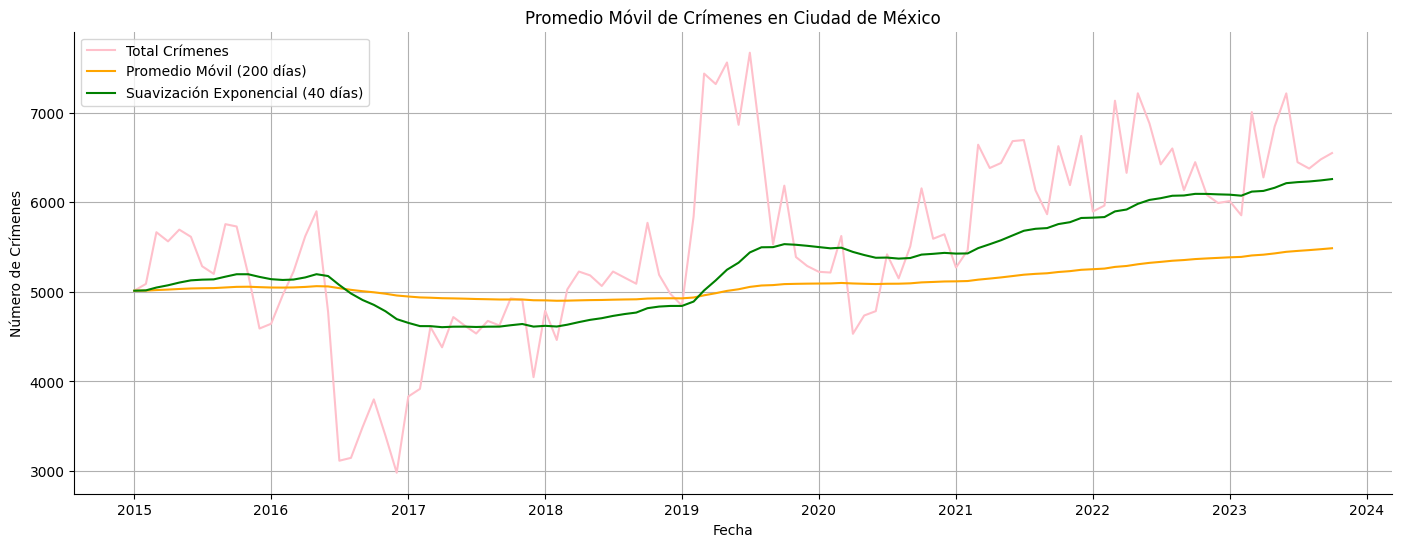

In [139]:
import matplotlib.pyplot as plt
import pandas as pd

# The previous cell 'za4KsIJFQ3iP' changes df to a Series.
# Convert the Series 'df' into a DataFrame and name the column 'Total_Crimes'.
# This ensures the 'Total_Crimes' column is available for subsequent operations.
if isinstance(df, pd.Series):
    df = df.to_frame(name='Total_Crimes')
else:
    print("Warning: 'df' is not a pandas Series. Please ensure previous data processing cells (from 9EVLe52IPwNy to za4KsIJFQ3iP) were executed correctly.")
    # If df is not a Series, it means the processing pipeline is broken. For robustness,
    # further operations will assume 'Total_Crimes' might not exist or will fail.

# Promedio Móvil Simple
ventana_sma = 200

# Only proceed with calculations and plotting if 'Total_Crimes' column exists
if 'Total_Crimes' in df.columns:
    df['SMA'] = df['Total_Crimes'].ewm(span=ventana_sma, adjust=False).mean()

    # Promedio Móvil Exponencial (Buscamos la tendencia)
    ventana_ses = 40
    df['SES'] = df['Total_Crimes'].ewm(span=ventana_ses, adjust=False).mean()

    # Graficar
    plt.figure(figsize=(17, 6))
    plt.plot(df['Total_Crimes'], label='Total Crímenes', color='pink') #Seasonal
    plt.plot(df['SMA'], label=f'Promedio Móvil ({ventana_sma} días)', color='orange')#Tendencia
    plt.plot(df['SES'], label=f'Suavización Exponencial ({ventana_ses} días)', color='green')#Resid
    plt.title('Promedio Móvil de Crímenes en Ciudad de México')
    plt.xlabel('Fecha')
    plt.ylabel('Número de Crímenes')
    plt.grid()
    plt.legend()
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.show()
else:
    print("Error: 'Total_Crimes' column could not be found or created. Please check earlier data processing steps.")

In [140]:
#Prueba de estacionariedad: Prueba de Dickey-Fuller aumentada (ADF)

#Hipótesis nula (H₀): La serie tiene una raíz unitaria (no es estacionaria).
#Hipótesis alternativa (H₁): La serie es estacionaria.

from statsmodels.tsa.stattools import adfuller

nivel_de_significancia = 0.05

# Realizar la prueba de Dickey-Fuller en los la tendencia
adf_test = adfuller(df['Total_Crimes'].dropna()) # Realiza la prueba ADF


# Interpretación de la prueba ADF
print('Estadístico ADF:', adf_test[0])
print('p-value:', adf_test[1])

if adf_test[1] <= nivel_de_significancia:
    print("La tendencia es estacionaria (rechazamos la hipótesis nula).")
else:
    print("La tendencia no es estacionaria (aceptamos la hipótesis nula).")

Estadístico ADF: -1.3547245401037937
p-value: 0.6037791659642472
La tendencia no es estacionaria (aceptamos la hipótesis nula).


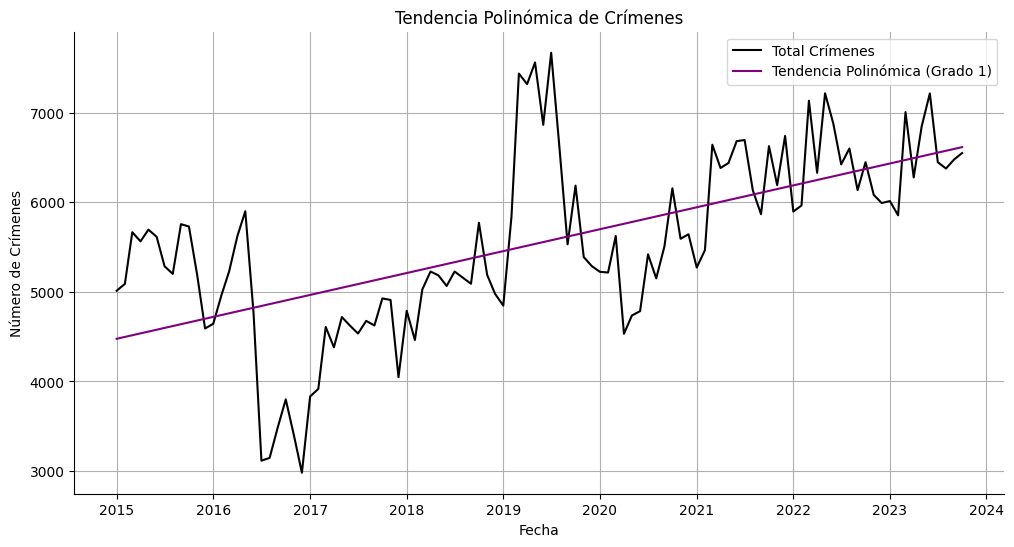

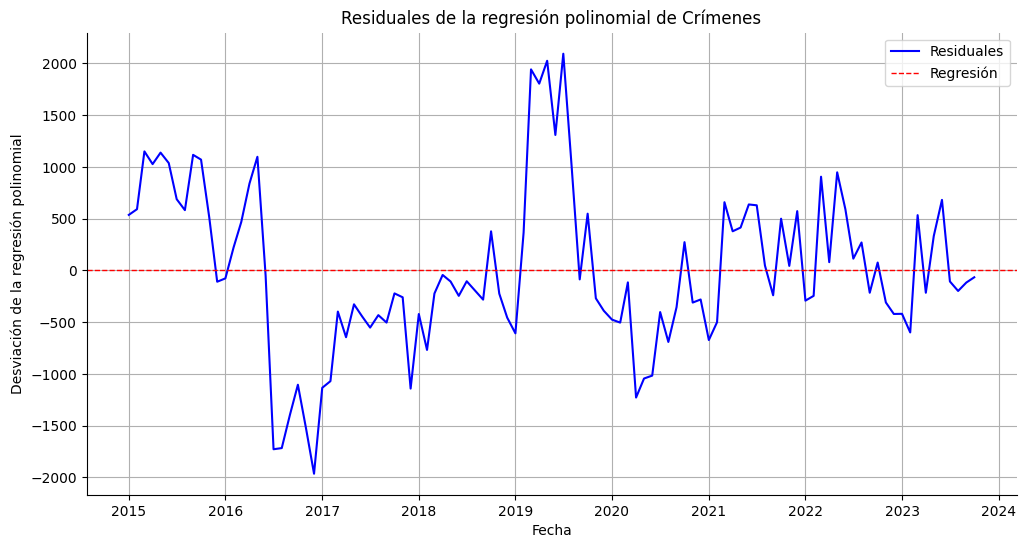

In [141]:
from numpy.polynomial.polynomial import Polynomial

# Paso 1: Convertir fechas a números
# Creamos una nueva columna llamada 'Date' la cual contiene las fechas en
# segundos desde el 1 de de enero de 1970 (tiempo UNIX)
df['Date'] = pd.to_datetime(df.index).map(pd.Timestamp.timestamp)

# Paso 2: Definir las variables independientes (X) y la variable dependiente (y)
X = df['Date']
y = df['Total_Crimes']

# Paso 3: Ajustar un modelo polinómico
grado = 1
modelo = Polynomial.fit(X, y, deg = grado)
df['Poly_Trend'] = modelo(X)
df['Poly_Resid'] = y - df['Poly_Trend']

# Graficar polinomial
# abre una nueva ventana gráfica
plt.figure(
    figsize=(12, 6) # tamaño (horizontal, vertical)
    )

# qué se va a graficar:
plt.plot(
    y,
    label='Total Crímenes', # etiqueta que aparecerá en la leyenda
    color='black'
    )

plt.plot(df['Poly_Trend'], label=f'Tendencia Polinómica (Grado {grado})', color='purple')
plt.title('Tendencia Polinómica de Crímenes') # Título
plt.xlabel('Fecha')                                           # nombre del eje x
plt.ylabel('Número de Crímenes')                            # nombre del eje y
plt.legend()                                                  # agrega la leyenda
plt.grid()                                                    # agrega una cuadrícula
plt.gca().spines['top'].set_visible(False)                    # elimina los bordes superiores
plt.gca().spines['right'].set_visible(False)                  # elimina los bordes derechos
plt.show()                                                    # muestra el gráfico (innecesario en colab)




# Graficar los residuales del polinomio
plt.figure(figsize=(12, 6)) # abre una nueva ventana gráfica
plt.plot(df['Poly_Resid'], label='Residuales', color='blue')
plt.axhline(0, color='red', label='Regresión',linestyle='--', linewidth=1)  # Línea horizontal en el valor cero
plt.title('Residuales de la regresión polinomial de Crímenes')
plt.xlabel('Fecha')
plt.ylabel('Desviación de la regresión polinomial')
plt.legend()
plt.grid()
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()

In [142]:
# Aquí no le muevan a nada
# Básicamente, lo que se hace este bloque es crear la función
# Transformada_de_Fourier, puesto a que no existe para lo que la quiero usar.

def Transformada_de_Fourier(serie, terminos, un_grafico):
  '''La función acepta los argumentos "serie", la cual debe de ser un array
  en numpy y en pandas de la forma df["my_variable"].values. Por otra parte,
  el parámetro "terminos" es un número natural que indica la cantidad de
  términos que desarrolla la serie. Entre mayor sea el número de términos,
  la serie será más precisa, pero más difícil de interpretar.

  La función tiene como salida una lista con los componentes sinosoidales de serie.
  El último elemento de la lista, es la suma de todos los componentes'''

  import numpy as np
  import matplotlib.pyplot as plt
  import pandas as pd
  from scipy.fftpack import fft, ifft

  # Supongamos que tienes una serie en df['AAPL_Close']
  # Reemplaza esta línea con tu DataFrame y serie específicos
  n = len(serie)

  # Calcular la transformada de Fourier
  transformada_fourier = fft(serie)

  # Obtener las frecuencias
  frecuencias = np.fft.fftfreq(n)

  # Crear un DataFrame para almacenar la frecuencia y su magnitud
  componentes = pd.DataFrame({
      'frecuencia': frecuencias,
      'magnitud': np.abs(transformada_fourier),
      'longitud_de_onda': 1 / frecuencias
  })

  # Ordenar el dataframe de mayor a menor en términos de magnitud

  componentes = componentes.sort_values(by='magnitud', ascending=False)

  # Seleccionar las frecuencias con mayor magnitud (excluyendo la frecuencia cero)
  top_frecuencias = componentes.loc[componentes['frecuencia'] > 0].nlargest(terminos, 'magnitud')
  top_frecuencias.reset_index(drop=True, inplace=True)
  print("Frecuencias principales:\n", top_frecuencias)

  # Crear el índice de tiempo para la serie
  t = np.arange(n)

  # Graficar cada componente de frecuencia junto con la serie original
  plt.figure(figsize=(12, 4))

  componente_temporal_sumado = np.zeros_like(serie)
  componentes_temporales = []

  n=0
  for i, row in top_frecuencias.iterrows():
      n+=1
      # Copiar la transformada de Fourier y mantener solo la frecuencia actual
      fourier_component = np.zeros_like(transformada_fourier)
      idx = np.where(frecuencias == row['frecuencia'])[0][0]  # índice de la frecuencia en la FFT
      fourier_component[idx] = transformada_fourier[idx]  # mantener solo la frecuencia positiva
      fourier_component[-idx] = transformada_fourier[-idx]  # mantener la frecuencia negativa correspondiente
      if n == (terminos+1):
        break

      # Reconstruir la señal en el tiempo
      componente_temporal = ifft(fourier_component).real
      componentes_temporales.append(componente_temporal)
      componente_temporal_sumado += componente_temporal

      # Graficar la componente
      plt.plot(
          componente_temporal,
          label=f'Longitud de onda {1 / row["frecuencia"]:.0f}',
          alpha=1,
          linewidth = 0.5,
          )
      plt.title('Componentes de Fourier de la Serie')
      plt.xlabel('Tiempo')
      plt.ylabel('Valor')
      plt.legend()
      plt.grid()

  componentes_temporales.append(componente_temporal_sumado)
  plt.plot(serie, label='Serie Original', color='black', alpha=0.5)
  if not un_grafico:
    plt.figure(figsize=(12, 4))
    plt.plot(serie, label='Serie Original', color='black', alpha=0.5)
  plt.plot(componente_temporal_sumado, label='Componente temporal sumada', color='red')
  plt.legend()
  plt.title('Suma de los Componentes de Fourier de la Serie')
  plt.xlabel('Tiempo')
  plt.ylabel('Valor')
  plt.grid()
  plt.show()

  return componentes_temporales

/tmp/ipykernel_581/76063994.py:34: RuntimeWarning: divide by zero encountered in divide
  'longitud_de_onda': 1 / frecuencias


Frecuencias principales:
    frecuencia      magnitud  longitud_de_onda
0    0.028302  25589.283309         35.333333
1    0.018868  24672.348930         53.000000
2    0.047170  18931.887449         21.200000
3    0.037736  16893.846169         26.500000
4    0.084906  16324.062692         11.777778


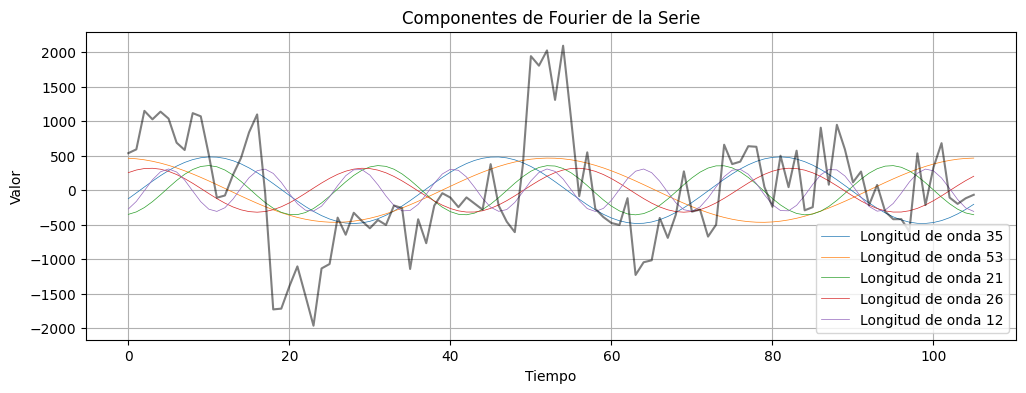

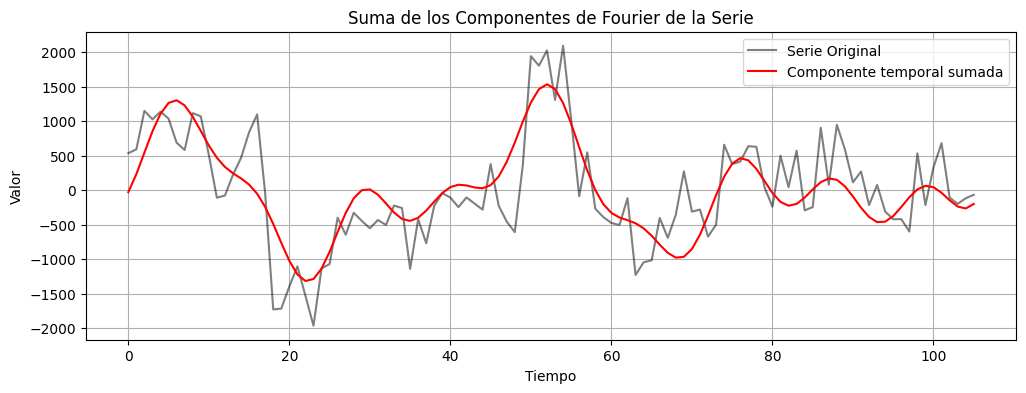

In [143]:
# Aquí no le muevan a nada
# Básicamente, lo que se hace este bloque es crear la función
# Transformada_de_Fourier, puesto a que no existe para lo que la quiero usar.

def Transformada_de_Fourier(serie, terminos, un_grafico):
  '''La función acepta los argumentos "serie", la cual debe de ser un array
  en numpy y en pandas de la forma df["my_variable"].values. Por otra parte,
  el parámetro "terminos" es un número natural que indica la cantidad de
  términos que desarrolla la serie. Entre mayor sea el número de términos,
  la serie será más precisa, pero más difícil de interpretar.

  La función tiene como salida una lista con los componentes sinosoidales de serie.
  El último elemento de la lista, es la suma de todos los componentes'''

  import numpy as np
  import matplotlib.pyplot as plt
  import pandas as pd
  from scipy.fftpack import fft, ifft

  # Supongamos que tienes una serie en df['AAPL_Close']
  # Reemplaza esta línea con tu DataFrame y serie específicos
  n = len(serie)

  # Calcular la transformada de Fourier
  transformada_fourier = fft(serie)

  # Obtener las frecuencias
  frecuencias = np.fft.fftfreq(n)

  # Crear un DataFrame para almacenar la frecuencia y su magnitud
  componentes = pd.DataFrame({
      'frecuencia': frecuencias,
      'magnitud': np.abs(transformada_fourier),
      'longitud_de_onda': 1 / frecuencias
  })

  # Ordenar el dataframe de mayor a menor en términos de magnitud

  componentes = componentes.sort_values(by='magnitud', ascending=False)

  # Seleccionar las frecuencias con mayor magnitud (excluyendo la frecuencia cero)
  top_frecuencias = componentes.loc[componentes['frecuencia'] > 0].nlargest(terminos, 'magnitud')
  top_frecuencias.reset_index(drop=True, inplace=True)
  print("Frecuencias principales:\n", top_frecuencias)

  # Crear el índice de tiempo para la serie
  t = np.arange(n)

  # Graficar cada componente de frecuencia junto con la serie original
  plt.figure(figsize=(12, 4))

  componente_temporal_sumado = np.zeros_like(serie)
  componentes_temporales = []

  i_count = 0 # Rename 'n' to 'i_count' to avoid conflict with 'n = len(serie)'
  for i, row in top_frecuencias.iterrows():
      i_count+=1
      # Copiar la transformada de Fourier y mantener solo la frecuencia actual
      fourier_component = np.zeros_like(transformada_fourier)
      idx = np.where(frecuencias == row['frecuencia'])[0][0]  # índice de la frecuencia en la FFT
      fourier_component[idx] = transformada_fourier[idx]  # mantener solo la frecuencia positiva
      fourier_component[-idx] = transformada_fourier[-idx]  # mantener la frecuencia negativa correspondiente
      if i_count == (terminos+1):
        break

      # Reconstruir la señal en el tiempo
      componente_temporal = ifft(fourier_component).real
      componentes_temporales.append(componente_temporal)
      componente_temporal_sumado += componente_temporal

      # Graficar la componente
      plt.plot(
          componente_temporal,
          label=f'Longitud de onda {1 / row["frecuencia"]:.0f}',
          alpha=1,
          linewidth = 0.5,
          )
      plt.title('Componentes de Fourier de la Serie')
      plt.xlabel('Tiempo')
      plt.ylabel('Valor')
      plt.legend()
      plt.grid()

  componentes_temporales.append(componente_temporal_sumado)
  plt.plot(serie, label='Serie Original', color='black', alpha=0.5)
  if not un_grafico:
    plt.figure(figsize=(12, 4))
    plt.plot(serie, label='Serie Original', color='black', alpha=0.5)
  plt.plot(componente_temporal_sumado, label='Componente temporal sumada', color='red')
  plt.legend()
  plt.title('Suma de los Componentes de Fourier de la Serie')
  plt.xlabel('Tiempo')
  plt.ylabel('Valor')
  plt.grid()
  plt.show()

  return componentes_temporales

serie = df['Poly_Resid'].values
terminos = 5
un_grafico = False

cts = Transformada_de_Fourier(serie, terminos, un_grafico)

# cts: componente temporal sumado


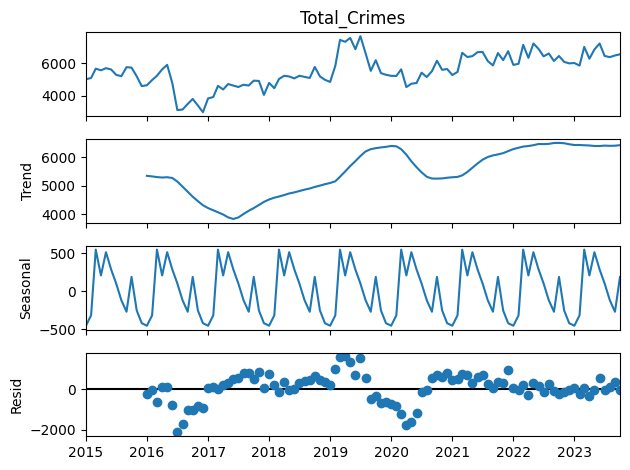

In [144]:
# Descomponer la serie temporal
import statsmodels.api as sm
import matplotlib.pyplot as plt

descomposicion = sm.tsa.seasonal_decompose(
    df['Total_Crimes'],
    model='additive',
    period=12,  # 12 meses en un año para datos mensuales
    extrapolate_trend=0,
    two_sided=False,
    )
fig = descomposicion.plot()
plt.show()

In [145]:
#Prueba de estacionariedad: Prueba de Dickey-Fuller aumentada (ADF)

#Hipótesis nula (H₀): La serie tiene una raíz unitaria (no es estacionaria).
#Hipótesis alternativa (H₁): La serie es estacionaria.

from statsmodels.tsa.stattools import adfuller

nivel_de_significancia = 0.05

# Realizar la prueba de Dickey-Fuller en los la tendencia
adf_test = adfuller(df['Total_Crimes'].dropna()) # Realiza la prueba ADF


# Interpretación de la prueba ADF
print('Estadístico ADF:', adf_test[0])
print('p-value:', adf_test[1])

if adf_test[1] <= nivel_de_significancia:
    print("La tendencia es estacionaria (rechazamos la hipótesis nula).")
else:
    print("La tendencia no es estacionaria (aceptamos la hipótesis nula).")

Estadístico ADF: -1.3547245401037937
p-value: 0.6037791659642472
La tendencia no es estacionaria (aceptamos la hipótesis nula).


# Resultados

A partir del procesamiento de la base de datos, se seleccionaron únicamente los registros correspondientes al estado de Puebla. Posteriormente, las fechas fueron transformadas a un formato adecuado para el análisis temporal, utilizando el año y el mes de cada registro. Después, los datos fueron agrupados por fecha para obtener el número total de delitos registrados en cada periodo mensual.

El primer resultado importante fue la construcción de una serie temporal mensual del total de crímenes en Puebla. Esta serie permitió observar la evolución de la incidencia delictiva a lo largo del tiempo y sirvió como base para los análisis posteriores.

También se aplicó un suavizamiento mediante media móvil exponencial, con el propósito de reducir el efecto de variaciones muy pequeñas o repentinas y visualizar con mayor claridad la tendencia general de los delitos. Este procedimiento permitió distinguir mejor el comportamiento de largo plazo frente a las fluctuaciones mensuales.

Posteriormente, se realizó la prueba de Dickey-Fuller aumentada para evaluar la estacionariedad de la serie. Esta prueba comparó el valor p con un nivel de significancia de 0.05. De acuerdo con la lógica establecida en el código, si el valor p es menor o igual a 0.05, la serie se considera estacionaria; en caso contrario, se interpreta como no estacionaria.

Además, se ajustó una tendencia polinómica de grado 1, es decir, una tendencia lineal, para representar el comportamiento general del total de crímenes. Esta gráfica permitió comparar los datos reales con la tendencia estimada y observar si, en términos generales, los delitos mostraban un aumento, una disminución o un comportamiento relativamente estable.

Después de calcular la tendencia, se obtuvieron los residuales de la regresión polinomial. Estos residuales permitieron analizar las diferencias entre los valores reales y los valores estimados por el modelo. Su representación gráfica ayudó a identificar momentos en los que los delitos estuvieron por encima o por debajo de la tendencia esperada.

También se aplicó la Transformada de Fourier a los residuales de la tendencia polinómica, utilizando cinco términos principales. Esta técnica permitió buscar patrones cíclicos dentro de las variaciones que no fueron explicadas por la tendencia lineal.

Finalmente, se realizó una descomposición aditiva de la serie temporal con un periodo de 12 meses. Esta descomposición permitió separar la serie en sus componentes principales: tendencia, estacionalidad y residuo. Gracias a este análisis, fue posible observar si existen comportamientos repetitivos relacionados con los meses del año.

En conjunto, los resultados muestran que el análisis de series temporales permite estudiar de una forma más profunda el comportamiento de los delitos en Puebla. No solo se observa el total de crímenes registrados, sino también la forma en que estos cambian con el tiempo, los posibles ciclos presentes y las variaciones que no son explicadas directamente por la tendencia.

#Conclusiones

Con base en el análisis realizado, se concluye que el estudio de los delitos mediante series temporales es una herramienta útil para comprender el comportamiento de la incidencia delictiva en el estado de Puebla. Al organizar los datos por fecha y sumar el total de crímenes mensuales, fue posible construir una visión más clara de cómo ha evolucionado este fenómeno a través del tiempo.

El uso de técnicas como el suavizamiento, la tendencia polinómica, la prueba de estacionariedad, la Transformada de Fourier y la descomposición estacional permitió analizar la serie desde diferentes perspectivas. Cada una de estas herramientas aportó información distinta: la tendencia mostró la dirección general de los datos, los residuales permitieron identificar desviaciones respecto al modelo, la prueba ADF ayudó a evaluar la estabilidad estadística de la serie y la descomposición permitió separar los componentes principales del comportamiento temporal.

También se puede concluir que los delitos no deben analizarse únicamente como cifras aisladas, sino como datos que forman parte de un comportamiento dinámico. Las variaciones en el número de crímenes pueden estar relacionadas con factores sociales, económicos, institucionales o estacionales, por lo que el análisis temporal ayuda a comprender mejor estos cambios.
Este proyecto demuestra la importancia del uso de herramientas computacionales para el análisis de información real. Python facilita la limpieza, transformación, visualización y modelado de datos, lo que permite obtener conclusiones más fundamentadas y comprensibles.

Finalmente, el análisis realizado puede servir como punto de partida para investigaciones más profundas. En trabajos futuros sería recomendable comparar Puebla con otros estados, incluir variables socioeconómicas o analizar los delitos por tipo específico. Esto permitiría obtener una interpretación más completa sobre los factores que influyen en la incidencia delictiva y contribuiría al diseño de estrategias de prevención más efectivas.

# Fue un placer trabajar con usted prof ⭐